## Возможности Персептрона

Архитектура, рассмотренная на прошлых заданиях, предложена Френком Розенблаттом в 1957 году. Такие нейросети использовались для классификации образов.

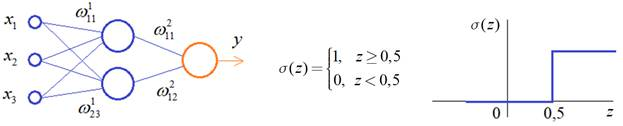

In [4]:
from IPython.display import Image

Image(filename='illustrations/Perceptron_1.jpg')

### 1. Бинарная классификация

Рассмотрим задачу классификации образов двух классов с двумя признаками $[x_1, x_2]^T$:

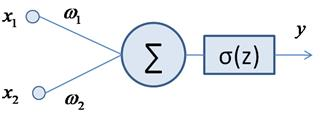

In [5]:
from IPython.display import Image

Image(filename='illustrations/Perceptron_2.jpg')

Функцию активации нейрона по-прежнему выберем пороговой:

$$
\sigma(z) = \begin{cases} +1, & z \ge 0 \\ -1, & z < 0 \end{cases} \rightarrow \begin{matrix} C_1 \\ C_2 \end{matrix}.
$$

То есть, если значение суммы больше или равно 0, то вектор принадлежит классу 1:
$$
[x_1, x_2]^T \in C_1,
$$

иначе, классу 2:
$$
[x_1, x_2]^T \in C_2.
$$

Далее, из вида функции активации видно, что граница разделения двух классов проходит на уровне есть, если:
$$
\begin{cases} \omega_1 x_1 + \omega_2 x_2 \ge 0 \rightarrow C_1 \\ \omega_1 x_1 + \omega_2 x_2 < 0 \rightarrow C_2 \end{cases}.
$$

Значит, сумма:
$$
\omega_1 x_1 + \omega_2 x_2 = 0,
$$

определяет границу разделения одного класса образов от другого. Ее также можно записать в виде:
$$
x_2 = -\frac{\omega_1}{\omega_2} x_1.
$$

То есть, это прямая с угловым коэффициентом
$$
k = -\frac{\omega_1}{\omega_2}.
$$

In [6]:
import torch
import matplotlib.pyplot as plt

В качестве примера смоделируем в Python два класса линейно-разделимых образов с разделяющей прямой:

$$
x_2 = 1 \cdot x_2,
$$

то есть, прямой, идущей под 45 градусов к осям координат. В этом случае для корректной классификации мы должны выбрать веса нейронной сети равными, но с противоположными знаками:

$$
k = 1 = -\frac{\omega_1}{\omega_2} \Rightarrow \omega_1 = -0.3, \quad \omega_2 = 0.3
$$

Класс 1
Класс 1
Класс 1
Класс 1
Класс 1


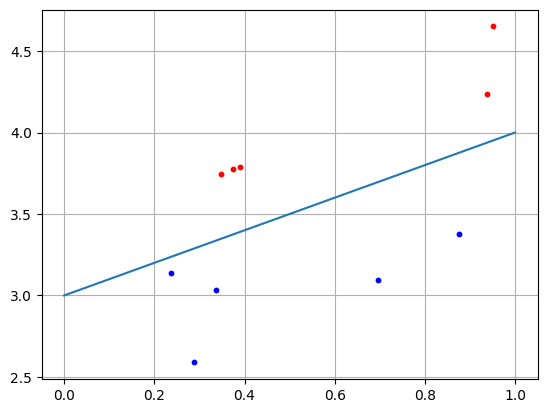

In [7]:
N = 5
b = 3

x1 = torch.rand(N)
x2 = x1 + torch.randint(1, 10, [N]) / 10 + b
C1 = torch.vstack([x1, x2, torch.ones(N)]).mT

x1 = torch.rand(N)
x2 = x1 - torch.randint(1, 10, [N]) / 10 + b
C2 = torch.vstack([x1, x2, torch.ones(N)]).mT

f = [0 + b, 1 + b]

w1 = -0.5
w2 = -w1
w3 = -b * w2
w = torch.FloatTensor([w1, w2, w3])

for i in range(N):
    x = C1[i, :]
    y = torch.dot(w, x)
    if y >= 0:
        print('Класс 1')
    else:
        print('Класс 2')

plt.scatter(C1[:, 0], C1[:, 1], s=10, c='red')
plt.scatter(C2[:, 0], C2[:, 1], s=10, c='blue')
plt.plot(f)
plt.grid()
plt.show()

Все точки по одну сторону от этой прямой будут относиться к одному классу, а по другую сторону – к другому классу. Такая прямая получила название разделяющей прямой. (В многомерном случае она превращается в гиперплоскость и называется разделяющей гиперплоскостью). Этот двумерный график хорошо демонстрирует возможность правильной классификации простейшим персептроном только линейно-разделимых образов.

### 2. Bias

Предположим, что все наши образы сдвигаются вверх по оси

Класс C2
Класс C2
Класс C2
Класс C2
Класс C2


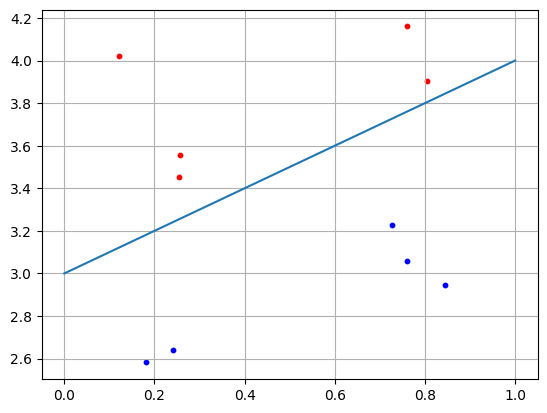

In [10]:
N = 5
b = 3

x1 = torch.rand(N)
x2 = x1 + torch.randint(1, 10, [N]) / 10 + b
C1 = torch.vstack([x1, x2, torch.ones(N)]).mT

x1 = torch.rand(N)
x2 = x1 - torch.randint(1, 10, [N]) / 10 + b
C2 = torch.vstack([x1, x2, torch.ones(N)]).mT

f = [0+b, 1+b]
y = [0, 1]
w1 = -0.5
w2 = -w1
w3 = -b * w2
w = torch.FloatTensor([w1, w2, w3])

for i in range(N):
    x = C2[:][i]
    y = torch.dot(w, x)
    if y >= 0:
        print("Класс C1")
    else:
        print("Класс C2")

plt.scatter(C1[:, 0], C1[:, 1], s=10, c='red')
plt.scatter(C2[:, 0], C2[:, 1], s=10, c='blue')
plt.plot(f)
plt.grid()
plt.show()

Теперь, наша разделяющая прямая не сможет верно классифицировать такие образы, т.к. она проходит через начало координат. И как бы мы ее ни крутили, корректного разделения не получится. Необходимо смещение. Поэтому, в НС дополнительно определяют еще один вход для смещения разделяющей гиперплоскости. В английской литературе он называется **bias** (смещение).

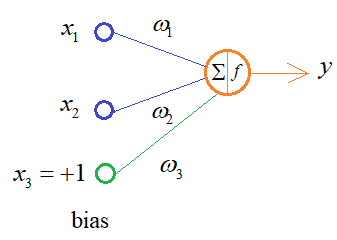

In [12]:
from IPython.display import Image

Image(filename='illustrations/Bias_1.png')

### 3. Задача XOR

Рассмотренная нами НС с одним нейроном, может классифицировать только линейно-разделимые образы. Однако на практике чаще встречаются более сложные задачи. Например, представим, что классы образов распределены по следующей схеме:

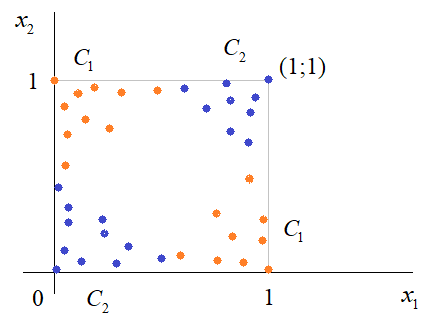

In [14]:
from IPython.display import Image

Image(filename='illustrations/XOR_1.png')

Здесь невозможно провести одну линию для их правильной классификации. Например, провести две линии, вот так:

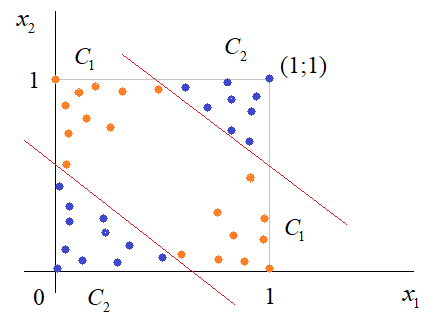

In [15]:
from IPython.display import Image

Image(filename='illustrations/XOR_2.png')

И все, что будет попадать между ними – отнесем к первому классу, а за их пределами – ко второму классу. Что это за НС, которая способна на такие операции? В действительности, все просто: каждая разделяющая линия может быть представлена отдельным нейроном, а затем, результат их классификации объединяется результирующим нейроном выходного слоя:

In [ ]:
from IPython.display import Image

Image(filename='illustrations/XOR_3.png')

Для простоты, будем полагать, что на входы подаются только значения 0 или 1:

$$
x_1, x_2 \in [0, 1].
$$

Тогда, все наши образы будут лежать в углах квадрата:

| \(x_1\) | \(x_2\) | Класс |
|---|---|---|
| 0 | 0 | \(C_2\) |
| 0 | 1 | \(C_1\) |
| 1 | 0 | \(C_1\) |
| 1 | 1 | \(C_2\) |

Если \(C_2 = 0, C_1 = 1\), то получаем таблицу истинности для битовой операции XOR (исключающее ИЛИ). Поэтому в литературе задача разделения таких образов получила название **задачи XOR**.

Далее, активационная функция каждого нейрона будет иметь вид:
$$
\sigma(z) = \begin{cases} 1, & z \ge 0 \\ 0, & z < 0 \end{cases}.
$$

Осталось определить веса связей НС для решения поставленной задачи классификации. Для начала, положим, что первый нейрон скрытого слоя будет формировать границу:

$$
x_2 = -1 \cdot x_1 + 1,5.
$$

Учитывая, нашу формулу:

$$
x_2 = -\frac{\omega_1}{\omega_2}x_1 - \frac{\omega_3}{\omega_2} \cdot 1.
$$

Веса входов первого нейрона для \(x_1, x_2\) можно взять равными:

$$
\omega_1 = \omega_2 = 1,
$$

а вес третьей связи:

$$
\omega_3 = -b \cdot \omega_2 = -1,5.
$$

Получили прямую, которая формирует следующее разделение на плоскости:

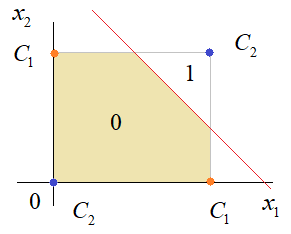

In [17]:
from IPython.display import Image

Image(filename='illustrations/XOR_4.png')   

Второй нейрон скрытого слоя будет формировать разделения прямой:

$$
x_2 = -1 \cdot x_1 + 0,5,
$$

и веса его связей можно взять равными:
$$
\omega_1 = \omega_2 = 1 \quad \text{и} \quad \omega_3 = -0,5.
$$

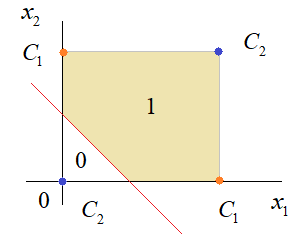

In [18]:
from IPython.display import Image

Image(filename='illustrations/XOR_5.png')   

Теперь, нам нужно объединить результаты их работы, чтобы получилась следующая разделяющая область:

In [ ]:
from IPython.display import Image

Image(filename='illustrations/XOR_6.png')   

Как выбрать веса для выходного нейрона, чтобы получить такую картину классификации? Если результаты просто сложить, то получим разделение вида и на выходе активационной функции увидим одну большую область с 1 и одну область с 0:

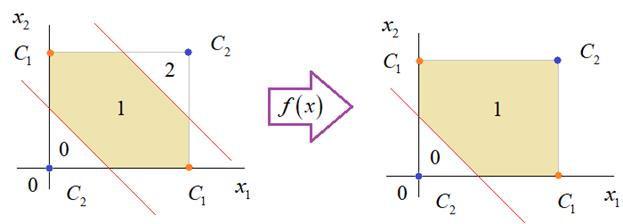

In [20]:
from IPython.display import Image

Image(filename='illustrations/XOR_7.jpg')   

Это не годится. Лучше из второго вычесть первое:

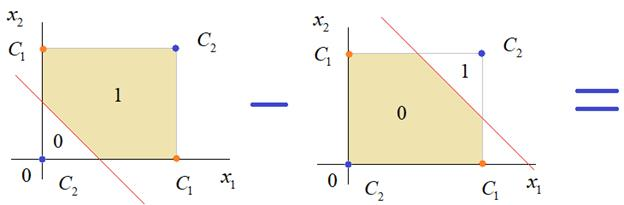

In [21]:
from IPython.display import Image

Image(filename='illustrations/XOR_8.jpg')   

И на входе выходного нейрона будем получать значения:

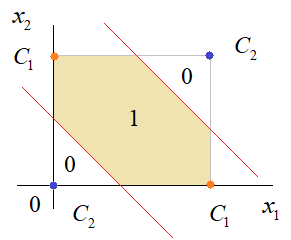

In [25]:
from IPython.display import Image

Image(filename='illustrations/XOR_9.png')   

Для надежности сместим эти значения на -0,5 и окончательно получим результат:

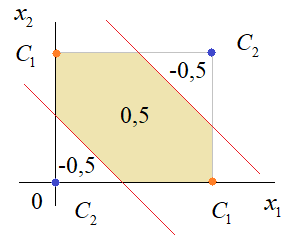

In [27]:
from IPython.display import Image

Image(filename='illustrations/XOR_10.png')   

То есть, веса в нашей НС, будут следующими:

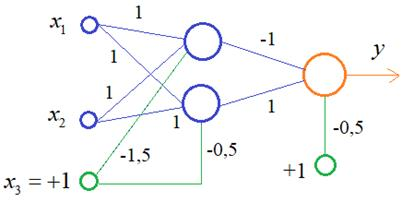

In [30]:
from IPython.display import Image

Image(filename='illustrations/XOR_11.jpg')   

In [16]:
def act(x):
    return 0 if x <= 0 else 1


w_hidden = torch.FloatTensor([[1, 1, -1.5], [1, 1, -0.5]])
w_out = torch.FloatTensor([-1, 1, -0.5])

# C1 = [(1,0), (0,1)]
# C2 = [(0,0), (1,1)]
data_x = [0, 0] # входные данные x1, x2
x = torch.FloatTensor(data_x + [1])

z_hidden = torch.matmul(w_hidden, x)
print(z_hidden)
u_hidden = torch.FloatTensor([act(x) for x in z_hidden] + [1])
print(u_hidden)

z_out = torch.dot(w_out, u_hidden)
y = act(z_out)
print(y)

tensor([-1.5000, -0.5000])
tensor([0., 0., 1.])
0


Важно отметить, что в этом блакноте все примеры содержали НС с уже известными весами. В реальных задачах, конечно, веса $\omega$ остаются неизвестными и их подбирает специальный алгоритм, который будет рассмотрен в следующем блаконте.